# N12 · Multi-probe $N\times2$pt analysis and a Fisher forecast for $\Omega_m$, $\sigma_8$

## Why combining probes sharpens cosmology

**Module 3 — Multi-wavelength large-scale-structure cosmology (PhD onboarding).**
This notebook assembles the two-point functions of galaxies and weak lensing into a joint
("$3\times2$pt") data vector, builds its Gaussian covariance, and runs a **Fisher forecast** for
$\Omega_m$ and $\sigma_8$. It is the pedagogical core of the thesis methodology, which extends this to
the $10\times2$pt combination of galaxies, shear, CMB lensing and tSZ (Fang et al. 2024).

**Key tool:** [CCL](https://ccl.readthedocs.io) angular power spectra and tracers.


### Learning objectives

1. Compute angular power spectra $C_\ell^{AB}$ with the Limber approximation using CCL tracers.
2. Assemble the $3\times2$pt data vector: clustering $gg$, galaxy–galaxy lensing $g\kappa$, shear $\kappa\kappa$.
3. Build the Gaussian (disconnected) covariance including shot and shape noise.
4. Form the Fisher matrix and read off marginalised errors on $\Omega_m$, $\sigma_8$.
5. Show quantitatively how adding lensing to clustering shrinks the $\Omega_m$–$\sigma_8$ ellipse.


## References

- Limber (1953), ApJ 117, 134 — the Limber approximation
  [doi:10.1086/145672](https://doi.org/10.1086/145672).
- LoVerde & Afshordi (2008), PRD 78, 123506 — extended Limber
  [arXiv:0809.5112](https://arxiv.org/abs/0809.5112).
- Tegmark, Taylor & Heavens (1997), ApJ 480, 22 — Fisher information in cosmology
  [arXiv:astro-ph/9603021](https://arxiv.org/abs/astro-ph/9603021).
- Krause & Eifler (2017), MNRAS 470, 2100 — CosmoLike covariances
  [arXiv:1601.05779](https://arxiv.org/abs/1601.05779).
- **Fang, Krause, Eifler et al. (2024), MNRAS 527, 9581** — $10\times2$pt methodology
  [arXiv:2308.01856](https://arxiv.org/abs/2308.01856).
- Chisari et al. (2019), ApJS 242, 2 — CCL
  [arXiv:1812.05995](https://arxiv.org/abs/1812.05995).


## 1. Angular power spectra and the Limber approximation

Each projected observable $A$ has a radial kernel $W_A(\chi)$. Under the Limber approximation
(Limber 1953; LoVerde & Afshordi 2008) the cross angular power spectrum is

$$\boxed{\;C_\ell^{AB} = \int_0^{\chi_H}\frac{d\chi}{\chi^2}\,W_A(\chi)\,W_B(\chi)\,
P\!\left(k=\frac{\ell+1/2}{\chi},\,z(\chi)\right)\;}$$

For **galaxy clustering** $W_g(\chi)=b(z)\,n(z)\,dz/d\chi$; for **weak lensing** $W_\kappa$ is the
lensing efficiency kernel of N09. CCL builds these tracers for us.


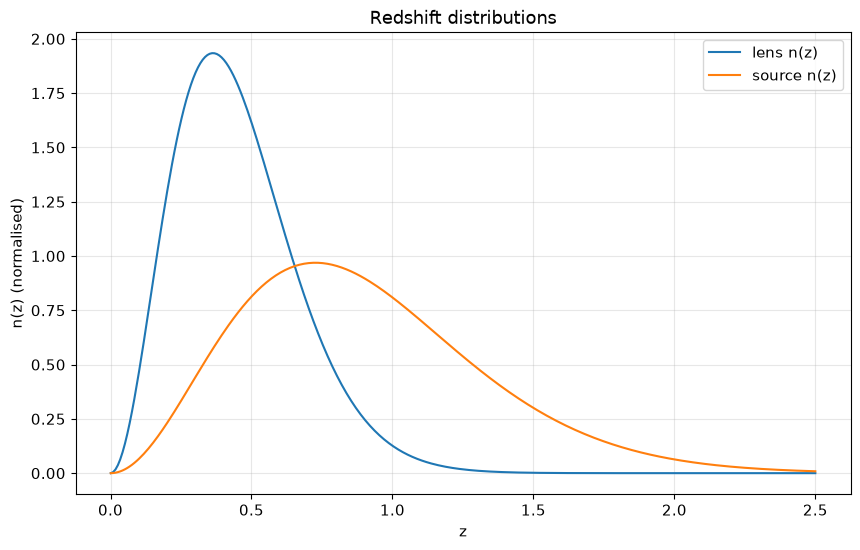

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyccl as ccl

plt.rcParams.update({'figure.figsize': (10, 6), 'font.size': 11, 'axes.grid': True,
                     'grid.alpha': 0.3})

def make_cosmo(Om=0.3153, s8=0.8111):
    Ob = 0.0493
    return ccl.Cosmology(Omega_c=Om - Ob, Omega_b=Ob, h=0.6736, n_s=0.9649, sigma8=s8)

cosmo = make_cosmo()

# Redshift distributions: a lens sample and a (deeper) source sample
z = np.linspace(0.001, 2.5, 300)
def smail(z, z0, alpha=2.0, b_=1.5):
    return z**alpha * np.exp(-(z/z0)**b_)
nz_lens = smail(z, z0=0.3); nz_lens /= np.trapezoid(nz_lens, z)
nz_src  = smail(z, z0=0.6); nz_src  /= np.trapezoid(nz_src, z)
bias = 1.5 * np.ones_like(z)

g_tr = ccl.NumberCountsTracer(cosmo, has_rsd=False, dndz=(z, nz_lens), bias=(z, bias))
k_tr = ccl.WeakLensingTracer(cosmo, dndz=(z, nz_src))

plt.figure()
plt.plot(z, nz_lens, label='lens n(z)')
plt.plot(z, nz_src, label='source n(z)')
plt.xlabel('z'); plt.ylabel('n(z) (normalised)'); plt.legend()
plt.title('Redshift distributions'); plt.show()


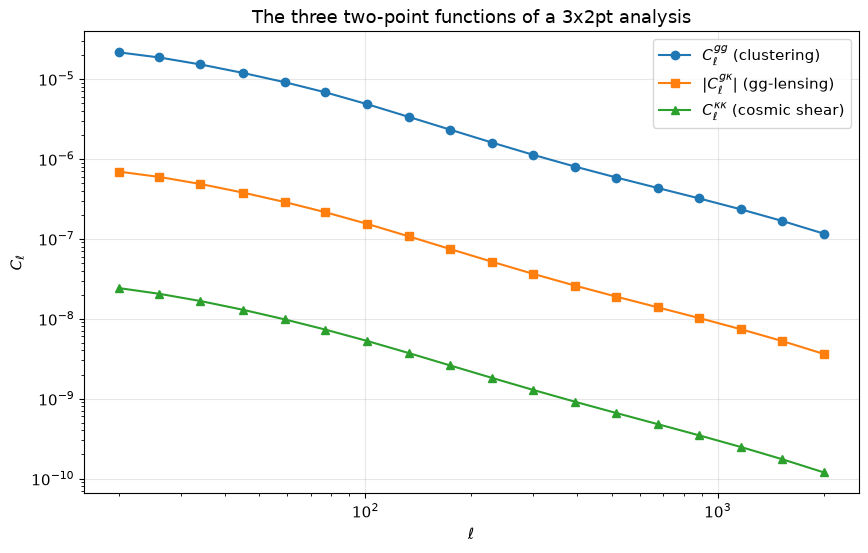

In [2]:
ell = np.unique(np.geomspace(20, 2000, 18).astype(int)).astype(float)
cl_gg = ccl.angular_cl(cosmo, g_tr, g_tr, ell)
cl_gk = ccl.angular_cl(cosmo, g_tr, k_tr, ell)
cl_kk = ccl.angular_cl(cosmo, k_tr, k_tr, ell)

plt.figure()
plt.loglog(ell, cl_gg, 'o-', label=r'$C_\ell^{gg}$ (clustering)')
plt.loglog(ell, np.abs(cl_gk), 's-', label=r'$|C_\ell^{g\kappa}|$ (gg-lensing)')
plt.loglog(ell, cl_kk, '^-', label=r'$C_\ell^{\kappa\kappa}$ (cosmic shear)')
plt.xlabel(r'$\ell$'); plt.ylabel(r'$C_\ell$'); plt.legend()
plt.title('The three two-point functions of a 3x2pt analysis')
plt.savefig('nx2pt_cls.png', dpi=130); plt.show()


## 2. Gaussian covariance with noise

For Gaussian fields the disconnected covariance of band-power estimates is (Tegmark, Taylor &
Heavens 1997; Krause & Eifler 2017)

$$\mathrm{Cov}\!\left(C_\ell^{AB},C_\ell^{CD}\right) =
\frac{\hat C_\ell^{AC}\hat C_\ell^{BD} + \hat C_\ell^{AD}\hat C_\ell^{BC}}
{(2\ell+1)\,f_{\rm sky}\,\Delta\ell},$$

where the *observed* spectra $\hat C_\ell$ include noise: shot noise $1/\bar n_g$ on $gg$ and shape
noise $\sigma_e^2/\bar n_\kappa$ on $\kappa\kappa$ (no noise on the cross term).


In [3]:
arcmin2_per_sr = (180*60/np.pi)**2
n_lens = 4.0 * arcmin2_per_sr        # 4 gal/arcmin^2 -> per steradian
n_src  = 10.0 * arcmin2_per_sr       # 10 src/arcmin^2
sigma_e = 0.26
f_sky = 0.4

N_gg = 1.0 / n_lens
N_kk = sigma_e**2 / n_src
Cgg_o, Cgk_o, Ckk_o = cl_gg + N_gg, cl_gk, cl_kk + N_kk

# bin widths
dl = np.gradient(ell)

def cov_3x2_at(i):
    # order of data vector blocks: (gg, gk, kk)
    gg, gk, kk = Cgg_o[i], Cgk_o[i], Ckk_o[i]
    norm = (2*ell[i] + 1) * f_sky * dl[i]
    C = np.array([
        [2*gg*gg,        2*gg*gk,         2*gk*gk     ],
        [2*gg*gk,        gg*kk + gk*gk,   2*gk*kk     ],
        [2*gk*gk,        2*gk*kk,         2*kk*kk     ],
    ]) / norm
    return C

print("3x3 covariance at ell=", ell[5], ":\n", cov_3x2_at(5))


3x3 covariance at ell= 77.0 :
 [[7.14573780e-14 2.25139572e-15 7.09343503e-17]
 [2.25139572e-15 7.67050405e-17 2.59854913e-18]
 [7.09343503e-17 2.59854913e-18 9.51930557e-20]]


## 3. The Fisher matrix

For a Gaussian likelihood with parameter-independent covariance, the Fisher matrix is
(Tegmark, Taylor & Heavens 1997)

$$F_{ij} = \sum_\ell \frac{\partial \mathbf{D}_\ell}{\partial\theta_i}^{\!\top}\,
\mathbf{C}_\ell^{-1}\,\frac{\partial \mathbf{D}_\ell}{\partial\theta_j},$$

with $\mathbf{D}_\ell=(C_\ell^{gg},C_\ell^{g\kappa},C_\ell^{\kappa\kappa})$. We differentiate the data
vector with respect to $\theta=(\Omega_m,\sigma_8)$ by central finite differences, then compare the
forecast from clustering alone (the $gg$ block) with the full $3\times2$pt.


In [4]:
def data_vector(Om, s8):
    c = make_cosmo(Om, s8)
    gt = ccl.NumberCountsTracer(c, has_rsd=False, dndz=(z, nz_lens), bias=(z, bias))
    kt = ccl.WeakLensingTracer(c, dndz=(z, nz_src))
    return (ccl.angular_cl(c, gt, gt, ell),
            ccl.angular_cl(c, gt, kt, ell),
            ccl.angular_cl(c, kt, kt, ell))

fid = dict(Om=0.3153, s8=0.8111)
steps = dict(Om=0.005, s8=0.005)

def deriv(param):
    p = fid[param]; h = steps[param]
    hi = data_vector(**{**fid, param: p + h})
    lo = data_vector(**{**fid, param: p - h})
    return [(hi[k] - lo[k]) / (2*h) for k in range(3)]   # [dCgg, dCgk, dCkk]

dD = {p: deriv(p) for p in ('Om', 's8')}
params = ['Om', 's8']

def fisher(blocks):
    F = np.zeros((2, 2))
    for i in range(len(ell)):
        C = cov_3x2_at(i)[np.ix_(blocks, blocks)]
        Cinv = np.linalg.inv(C)
        for a, pa in enumerate(params):
            for b, pb in enumerate(params):
                va = np.array([dD[pa][k][i] for k in blocks])
                vb = np.array([dD[pb][k][i] for k in blocks])
                F[a, b] += va @ Cinv @ vb
    return F

F_gg   = fisher([0])           # clustering only
F_3x2  = fisher([0, 1, 2])     # full 3x2pt

for name, F in [('clustering only', F_gg), ('3x2pt', F_3x2)]:
    cov = np.linalg.inv(F)
    print(f"{name:16s}: sigma(Om)={np.sqrt(cov[0,0]):.4f}  sigma(s8)={np.sqrt(cov[1,1]):.4f}"
          f"  FoM={1/np.sqrt(np.linalg.det(cov)):.1f}")


clustering only : sigma(Om)=0.0049  sigma(s8)=0.0009  FoM=630995.0
3x2pt           : sigma(Om)=0.0005  sigma(s8)=0.0003  FoM=6006820.4


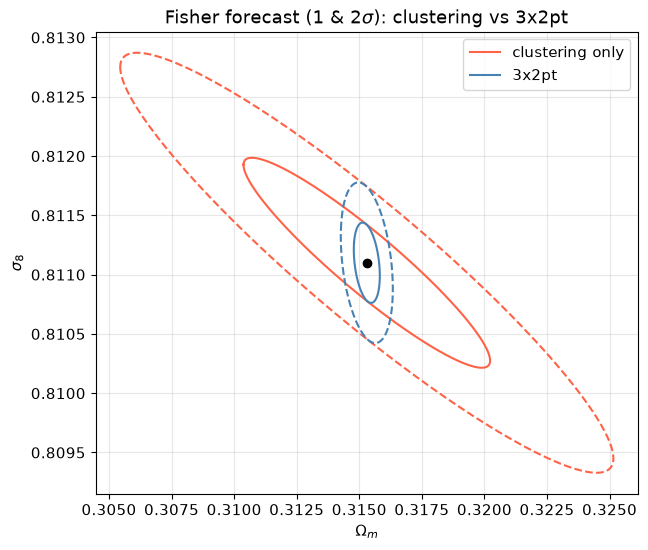

In [5]:
def ellipse(cov, mean, nsig=1, **kw):
    vals, vecs = np.linalg.eigh(cov)
    order = np.argsort(vals)[::-1]; vals, vecs = vals[order], vecs[:, order]
    ang = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    a, b = nsig * np.sqrt(vals)
    t = np.linspace(0, 2*np.pi, 200)
    xy = np.array([a*np.cos(t), b*np.sin(t)])
    R = np.array([[np.cos(np.radians(ang)), -np.sin(np.radians(ang))],
                  [np.sin(np.radians(ang)),  np.cos(np.radians(ang))]])
    xy = R @ xy
    plt.plot(mean[0] + xy[0], mean[1] + xy[1], **kw)

mean = [fid['Om'], fid['s8']]
plt.figure(figsize=(7, 6))
for F, c, lab in [(F_gg, 'tomato', 'clustering only'), (F_3x2, 'steelblue', '3x2pt')]:
    cov = np.linalg.inv(F)
    ellipse(cov, mean, 1, color=c, label=lab)
    ellipse(cov, mean, 2, color=c, ls='--')
plt.scatter(*mean, color='k', zorder=5)
plt.xlabel(r'$\Omega_m$'); plt.ylabel(r'$\sigma_8$')
plt.title('Fisher forecast (1 & 2$\\sigma$): clustering vs 3x2pt'); plt.legend()
plt.savefig('nx2pt_fisher_ellipses.png', dpi=130); plt.show()


## 4. Autodiff Fisher with JAX

The finite-difference derivatives above can be replaced by **exact** ones from automatic
differentiation. We build a self-contained JAX cosmic-shear pipeline (distances + growth + Limber over
the BBKS $P(k)$, as in N09), take its Jacobian $\partial C_\ell/\partial\theta$ with `jax.jacfwd`, and
form the Fisher matrix $F=J^\top\,\mathrm{Cov}^{-1}\,J$ with the same shape-noise covariance. No finite
step size to tune, and the gradient cost is independent of the number of multipoles — the property the
thesis exploits at scale.


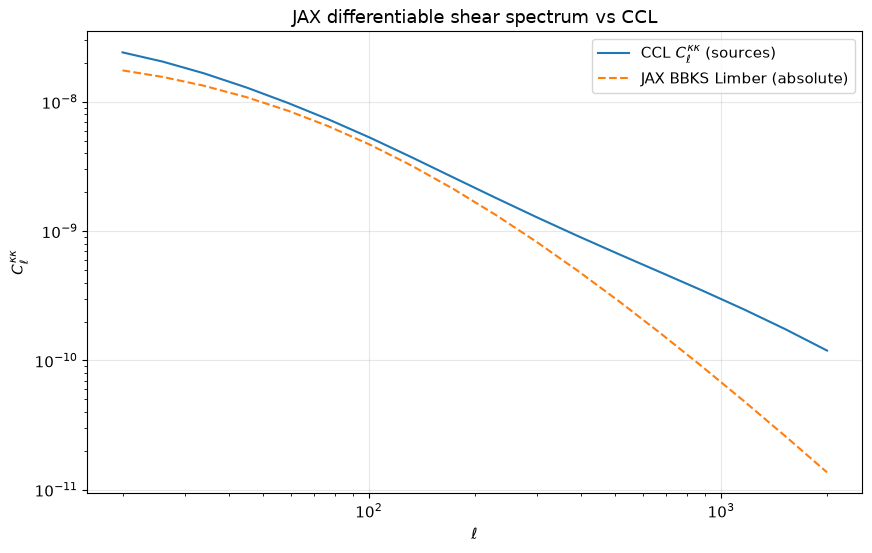

In [6]:
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
from astropy.constants import c as c_light
from astropy.cosmology import Planck18

hh, nsx = 0.6736, 0.9649
DH = float((c_light/Planck18.H0).to('Mpc').value)
zg = jnp.linspace(1e-3, 3.0, 256); ag = jnp.linspace(1e-3, 1.0, 256)
kgn = jnp.logspace(-3.0, 1.2, 400)
nzs = zg**2*jnp.exp(-(zg/0.6)**1.5); nzs = nzs/jnp.trapezoid(nzs, zg)   # source n(z), matches src tracer

def Eofz(z, Om): return jnp.sqrt(Om*(1+z)**3 + (1-Om))
def Eofa(a, Om): return jnp.sqrt(Om*a**-3 + (1-Om))
def chigrid(Om):
    iE = 1/Eofz(zg, Om); dz = jnp.diff(zg)
    return DH*jnp.concatenate([jnp.zeros(1), jnp.cumsum(0.5*(iE[1:]+iE[:-1])*dz)])
def Dgrid(Om):
    ig = 1/(ag*Eofa(ag, Om))**3; da = jnp.diff(ag)
    cum = jnp.concatenate([jnp.zeros(1), jnp.cumsum(0.5*(ig[1:]+ig[:-1])*da)])
    D = Eofa(ag, Om)*cum; return D/D[-1]
def Tb(k, G):
    q = k/G
    return jnp.log(1+2.34*q)/(2.34*q)*(1+3.89*q+(16.1*q)**2+(5.46*q)**3+(6.71*q)**4)**-0.25
def shp(k, Om): return k**nsx*Tb(k, Om*hh)**2
def s8raw(Om):
    x = kgn*8; W = 3*(jnp.sin(x)-x*jnp.cos(x))/x**3
    d2 = kgn**3*shp(kgn, Om)/(2*jnp.pi**2); return jnp.sqrt(jnp.trapezoid(d2*W**2, jnp.log(kgn)))

def clkk(l, Om, s8):
    chi = chigrid(Om); chi_pos = jnp.maximum(chi, 1e-6)
    Dz = jnp.interp(1/(1+zg), ag, Dgrid(Om)); amp = (s8/s8raw(Om))**2
    qi = jax.vmap(lambda i: jnp.trapezoid(
            nzs*(1-chi[i]/chi_pos)*(jnp.arange(zg.size) > i), zg)
         )(jnp.arange(zg.size))
    W = 1.5*Om/DH**2*(1+zg)*chi*qi
    k = (l+0.5)/chi_pos/hh
    P = amp*shp(k, Om)*Dz**2/hh**3
    return jnp.sum(W**2/chi_pos**2*P*jnp.gradient(chi))

Dvec = lambda th: jax.vmap(lambda l: clkk(l, th[0], th[1]))(jnp.asarray(ell))
theta0 = jnp.array([0.3153, 0.8111])
cl_jax = np.array(Dvec(theta0))
plt.figure()
plt.loglog(ell, cl_kk, label=r'CCL $C_\ell^{\kappa\kappa}$ (sources)')
plt.loglog(ell, cl_jax, '--', label='JAX BBKS Limber (absolute)')
plt.xlabel(r'$\ell$'); plt.ylabel(r'$C_\ell^{\kappa\kappa}$'); plt.legend()
plt.title('JAX differentiable shear spectrum vs CCL'); plt.show()


autodiff shear Fisher:
  sigma(Omega_m) = 0.0079
  sigma(sigma8)  = 0.0165
  correlation    = -0.987  (the S8 banana)


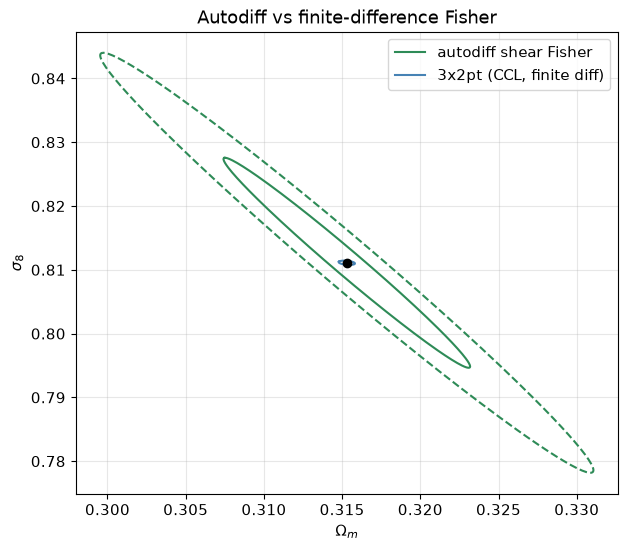

In [7]:
# Autodiff Jacobian -> Fisher (shear-only), with the same shape-noise covariance
J = np.array(jax.jacfwd(Dvec)(theta0))            # (n_ell, 2)
Ckk_obs = cl_jax + N_kk
cov_l = 2*Ckk_obs**2/((2*ell + 1)*f_sky*dl)       # Gaussian shear covariance per ell
F_ad = np.einsum('la,lb,l->ab', J, J, 1.0/cov_l)
cov_ad = np.linalg.inv(F_ad)
print("autodiff shear Fisher:")
print(f"  sigma(Omega_m) = {np.sqrt(cov_ad[0,0]):.4f}")
print(f"  sigma(sigma8)  = {np.sqrt(cov_ad[1,1]):.4f}")
print(f"  correlation    = {cov_ad[0,1]/np.sqrt(cov_ad[0,0]*cov_ad[1,1]):+.3f}  (the S8 banana)")

plt.figure(figsize=(7, 6))
ellipse(cov_ad, [0.3153, 0.8111], 1, color='seagreen', label='autodiff shear Fisher')
ellipse(cov_ad, [0.3153, 0.8111], 2, color='seagreen', ls='--')
ellipse(np.linalg.inv(F_3x2), mean, 1, color='steelblue', label='3x2pt (CCL, finite diff)')
plt.scatter(0.3153, 0.8111, color='k', zorder=5)
plt.xlabel(r'$\Omega_m$'); plt.ylabel(r'$\sigma_8$')
plt.title('Autodiff vs finite-difference Fisher'); plt.legend()
plt.savefig('nx2pt_autodiff_fisher.png', dpi=130); plt.show()


## 5. Toward $N\times2$pt: adding gas probes

The thesis goes beyond $3\times2$pt. Fang et al. (2024) combine **ten** correlated two-point functions
from galaxy position, galaxy shear, CMB lensing convergence and the tSZ (Compton-$y$) field — a
$10\times2$pt analysis — and show that adding the tSZ cross-correlations significantly improves the
$\Omega_m$–$S_8$ figure of merit while *self-calibrating* the gas/feedback physics (Fang et al. 2024).
Conceptually, every probe added contributes new rows/blocks to $\mathbf{D}_\ell$ and the covariance;
the same Fisher machinery above then propagates the gain. The X-ray (N11) and SZ (N10) observables
enter here as additional fields whose astrophysical parameters are marginalised jointly with
$\Omega_m,\sigma_8$.


## Exercises

1. **Shape-noise dependence.** Halve $\sigma_e$ (better shape measurement) and recompute the 3x2pt
   ellipse. Which probe benefits most?
2. **Sky area.** Scale errors with $f_{\rm sky}$: verify $\sigma(\theta)\propto f_{\rm sky}^{-1/2}$ by
   running $f_{\rm sky}\in\{0.1,0.4,0.7\}$.
3. **$S_8$ direction.** Rotate the Fisher matrix into $(\Omega_m, S_8=\sigma_8\sqrt{\Omega_m/0.3})$ and
   show the 3x2pt ellipse is much rounder in this basis — lensing constrains $S_8$.
4. **Bias degeneracy.** Add linear galaxy bias $b$ as a third free parameter and marginalise. By how
   much does $\sigma(\sigma_8)$ degrade for clustering-only, and why does lensing break the degeneracy?


## Summary

- Projected observables combine into angular power spectra via the Limber integral.
- The $3\times2$pt data vector $(gg,g\kappa,\kappa\kappa)$ with a Gaussian covariance yields a Fisher
  forecast; adding lensing to clustering shrinks the $\Omega_m$–$\sigma_8$ ellipse markedly.
- The thesis extends this to $N\times2$pt with CMB lensing and tSZ (Fang et al. 2024), self-calibrating
  feedback while tightening cosmology.
- The Fisher derivatives can be obtained exactly by **autodiff** (`jax.jacfwd`) instead of finite
  differences — no step size to tune, gradient cost independent of data-vector length.

**Next (N13):** replace the Fisher approximation with a full **differentiable** forward model sampled
by Hamiltonian / micro-canonical Monte Carlo.
